In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv('main_data.csv')

In [3]:
df.head()

,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
0,0,AFG,33.70269,34.53602,34.53602
1,1,AGO,64.57157,65.32993,64.99177
2,2,ALB,52.60171,52.67715,52.64734
3,3,ARE,86.51006,89.75407,86.52729
4,4,ARG,48.96341,56.44015,49.26822


In [4]:
df.tail()

,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
186,186,XKX,50.29844,55.28702,52.87432
187,187,YEM,0.00000,0.00000,0.00000
188,188,ZAF,68.26741,68.32331,68.24925
189,189,ZMB,71.10859,72.09460,71.72488
190,190,ZWE,46.39289,60.00173,48.55427


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 191 non-null    int64  
 1   country                                    191 non-null    str    
 2   fy2017, Dealing with construction permits  191 non-null    float64
 3   fy2019, Dealing with construction permits  191 non-null    float64
 4   fy2018, Dealing with construction permits  191 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 7.6 KB


In [7]:
df.describe()

,Unnamed: 0,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
count,191.0000,191.000000,191.000000,191.000000
mean,95.0000,63.269214,65.845667,64.770344
std,55.2811,16.622900,15.815424,15.707923
min,0.0000,0.000000,0.000000,0.000000
25%,47.5000,56.300935,59.640150,57.710025
50%,95.0000,66.694200,68.683240,67.943670
75%,142.5000,73.407800,75.182955,73.913715
max,190.0000,91.210020,93.467020,91.241050


In [8]:
df.isnull().sum()

Unnamed: 0                                   0
country                                      0
fy2017, Dealing with construction permits    0
fy2019, Dealing with construction permits    0
fy2018, Dealing with construction permits    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

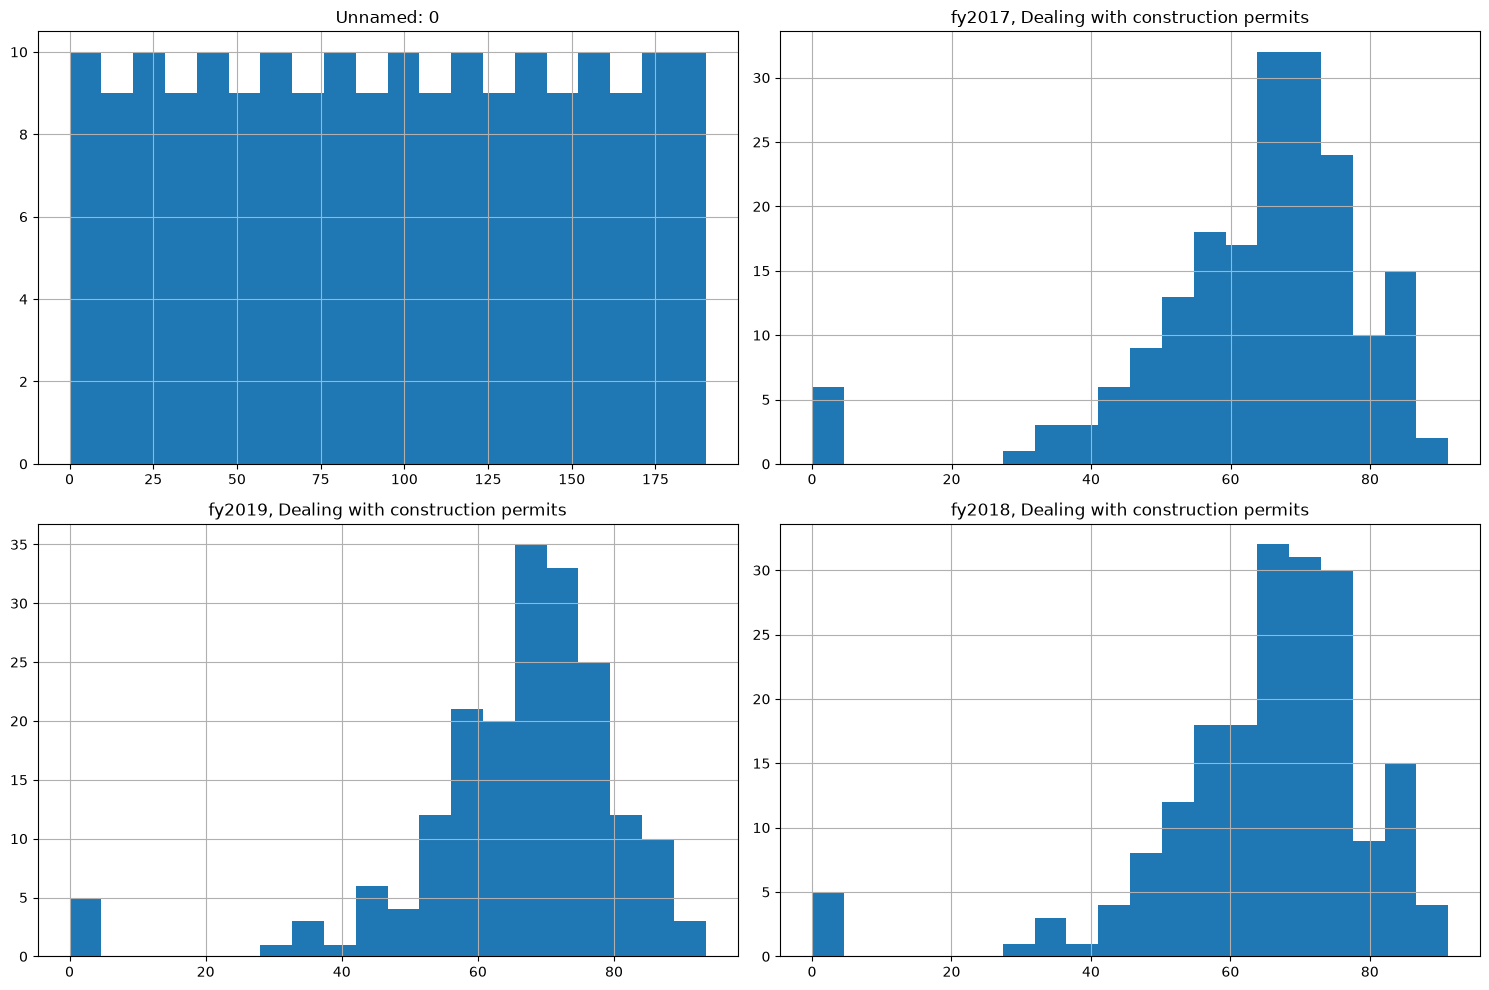

In [11]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

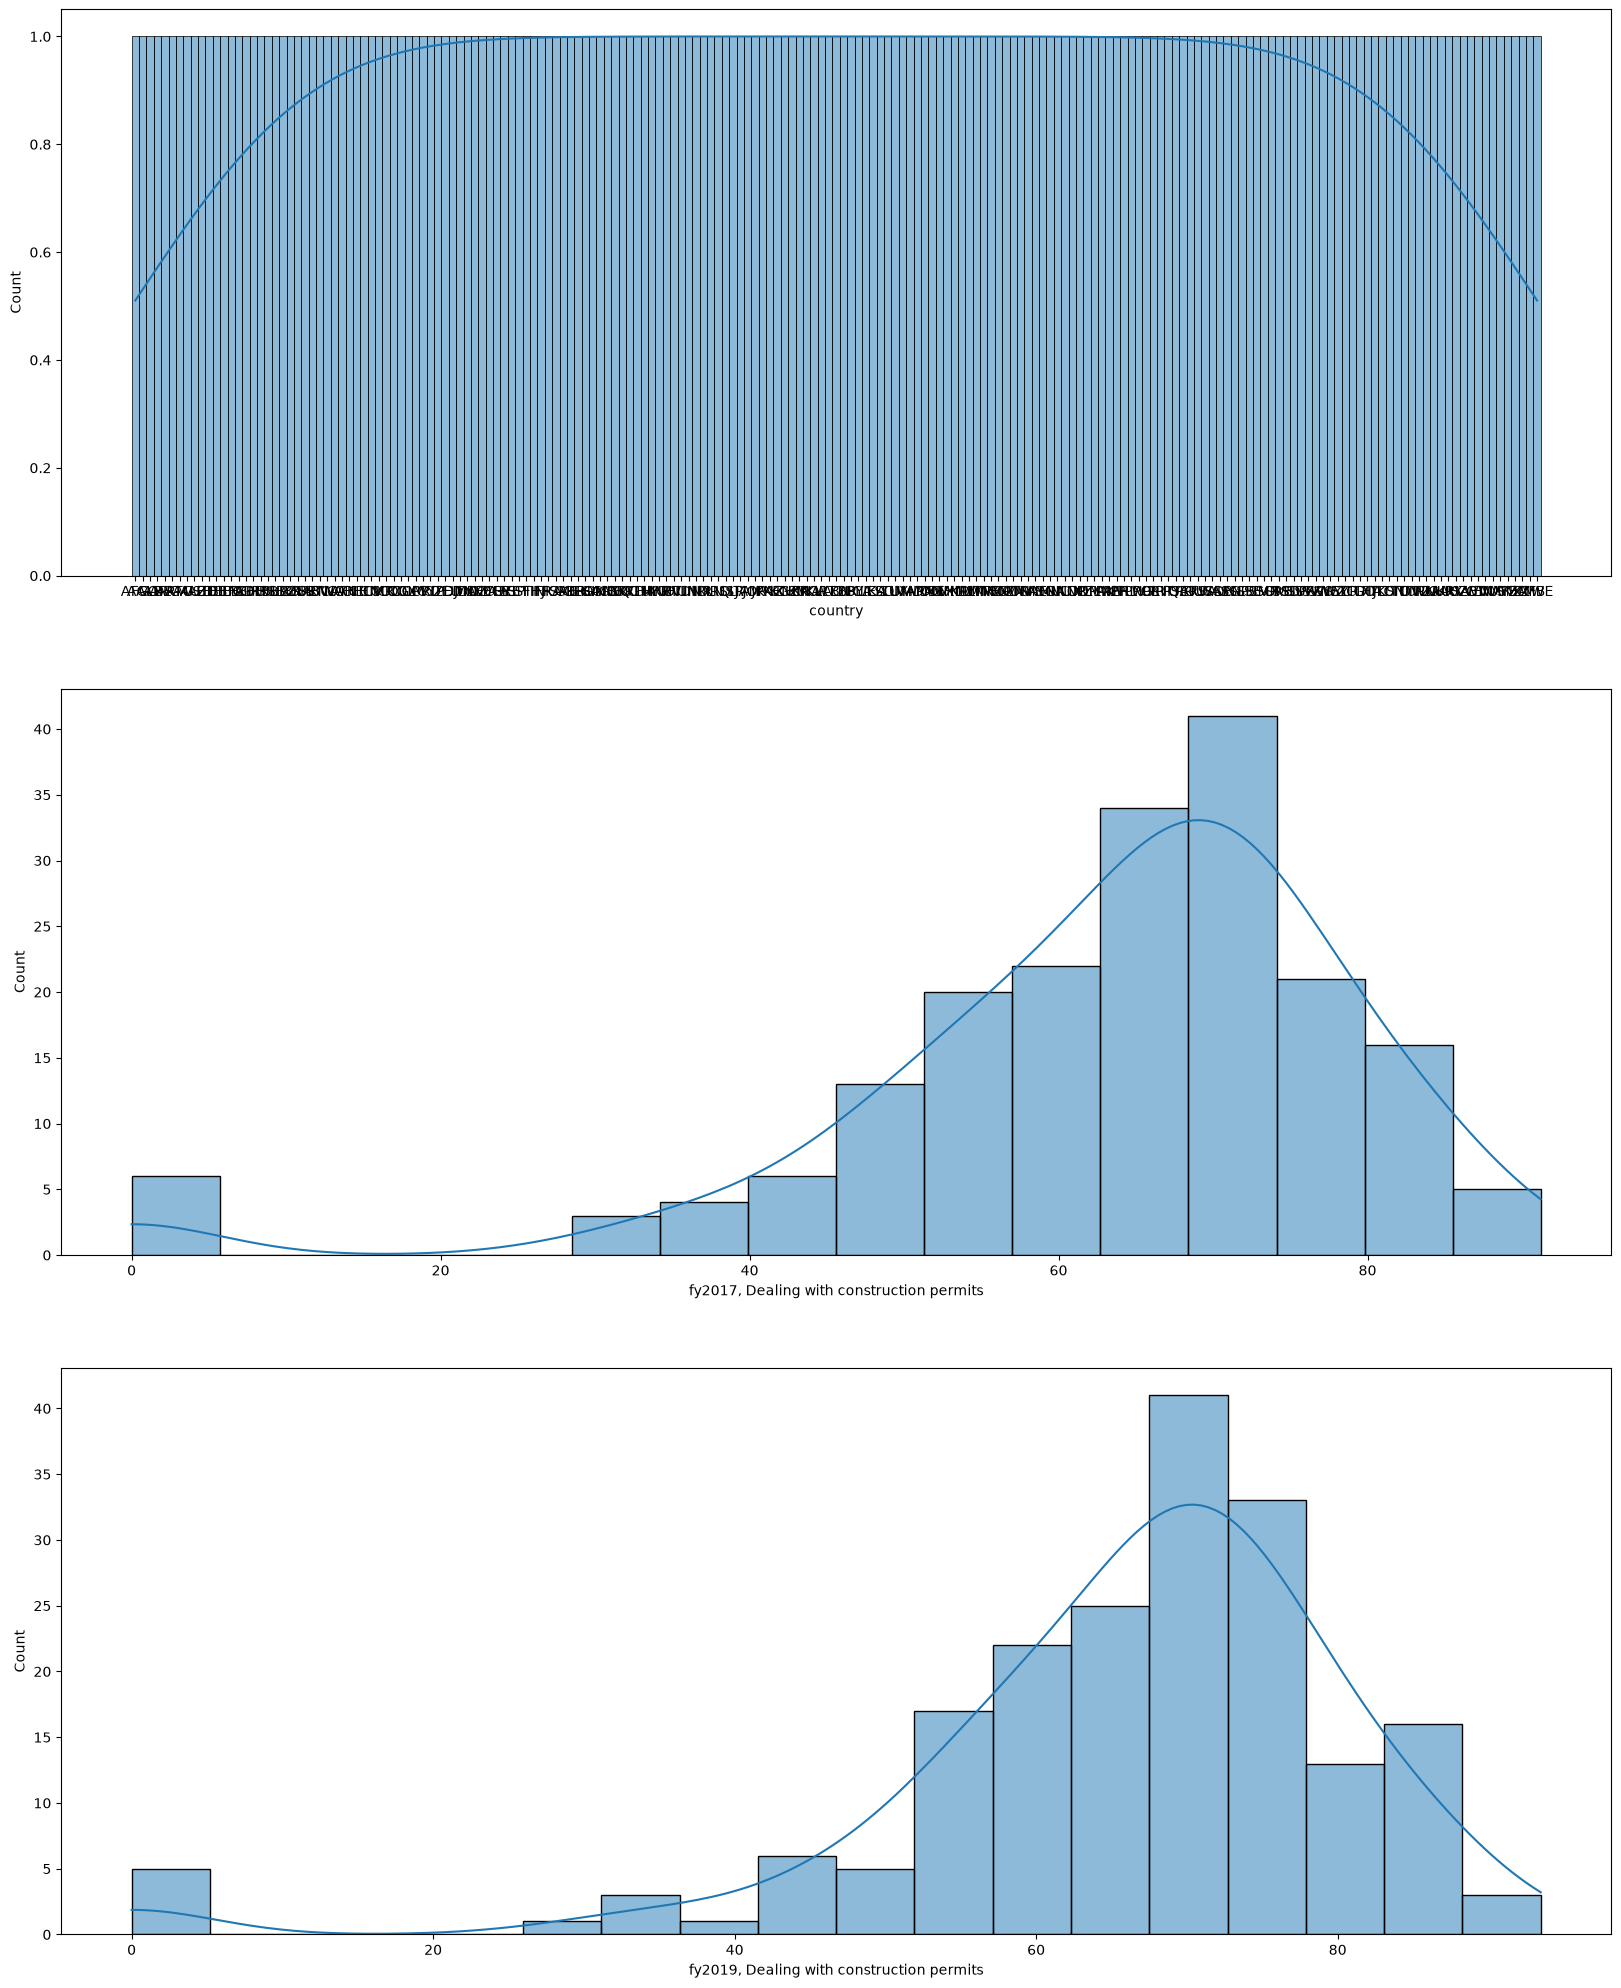

In [14]:
## Exploratory Data Analysis (EDA)

plt.figure(figsize=(20,25))                    # Create a large figure
for i in range(1,4):                           # Loop through columns 1 to 3
    plt.subplot(3,1,i)                         # Create 3 rows and 1 column of plots
    sns.histplot(df.iloc[:,i], kde=True)       # Plot histogram with KDE curve

plt.show()

In [28]:
## Select Features

X = df.iloc[:,2:] # Select numerical columns for clustering
X.columns

Index(['fy2017, Dealing with construction permits',
       'fy2019, Dealing with construction permits',
       'fy2018, Dealing with construction permits'],
      dtype='str')

In [29]:
## Elbow Method

wcss = [] # Empty list to store WCSS values
for i in range(1,12): # Try K values from 1 to 11
    kmeans = KMeans(n_clusters=i, random_state=42) # Create KMeans model
    kmeans.fit(X) # Train model on dataset
    wcss.append(kmeans.inertia_) # Store WCSS value

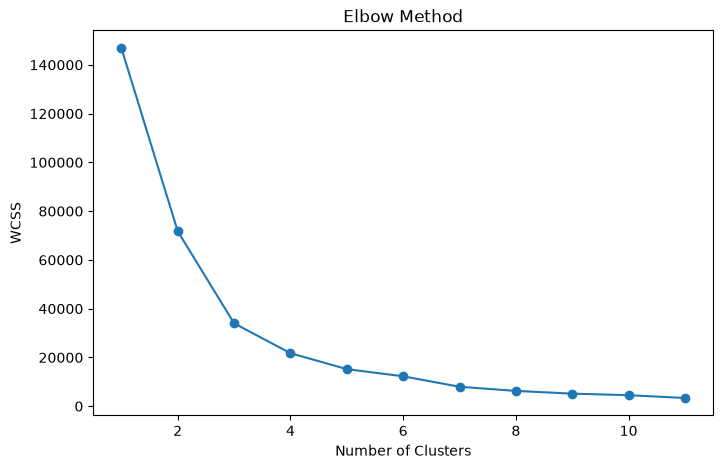

In [30]:
## Plot Elbow Graph

plt.figure(figsize=(8,5)) # Create graph
plt.plot(range(1,12), wcss, marker='o') # Plot K vs WCSS
plt.title("Elbow Method") # Graph title
plt.xlabel("Number of Clusters") # X-axis label
plt.ylabel("WCSS") # Y-axis label
plt.show() # Display graph

In [32]:
## Train Final Model

model = KMeans(n_clusters=3, random_state=42) # Create final model with K=3
model.fit(X) # Train model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[

In [33]:
## Cluster Labels
label = model.labels_ # Get cluster number for each data point
print(label)

## Cluster Centers
print(model.cluster_centers_) # Display centroid of each cluster

## Count Records
from collections import Counter # Import Counter
print(Counter(label)) # Count records in each cluster

## Predict New Data
new_point = [[15,40,100]] # New sample
prediction = model.predict(new_point) # Predict cluster
print(prediction) # Display predicted cluster

## Add Cluster Labels
df["Labels"] = label # Create new Labels column
df.head() # Display updated dataset

[0 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 2 1 1 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 2 2 1 0 1 0 1 1 1 1 0 0 1 1 1
 1 0 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1
 0 1 0 0 0 1 2 1 0 1 1 0 1 1 1 1 2 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 0
 1 0 2 1 1 0]
[[51.37082446 56.48001462 54.70178385]
 [72.63648108 73.969857   73.22151008]
 [ 4.82308667  4.82308667  4.82308667]]
Counter({np.int32(1): 120, np.int32(0): 65, np.int32(2): 6})
[0]


,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits",Labels
0,0,AFG,33.70269,34.53602,34.53602,0
1,1,AGO,64.57157,65.32993,64.99177,1
2,2,ALB,52.60171,52.67715,52.64734,0
3,3,ARE,86.51006,89.75407,86.52729,1
4,4,ARG,48.96341,56.44015,49.26822,0


In [35]:
## Average of Cluster 0

print(df.loc[df["Labels"]==0].iloc[:,2].mean()) # Average of column3
print(df.loc[df["Labels"]==0].iloc[:,3].mean()) # Average of column1
print(df.loc[df["Labels"]==0].iloc[:,4].mean()) # Average of column2

## Average of Cluster 1
print(df.loc[df["Labels"]==1].iloc[:,2].mean()) # Average of column3
print(df.loc[df["Labels"]==1].iloc[:,3].mean()) # Average of column1
print(df.loc[df["Labels"]==1].iloc[:,4].mean()) # Average of column2

## Average of Cluster 2
print(df.loc[df["Labels"]==2].iloc[:,2].mean()) # Average of column3
print(df.loc[df["Labels"]==2].iloc[:,3].mean()) # Average of column1
print(df.loc[df["Labels"]==2].iloc[:,4].mean()) # Average of column2

51.37082446153846
56.48001461538461
54.701783846153845
72.63648108333334
73.96985699999999
73.22151008333334
4.823086666666667
4.823086666666667
4.823086666666667


In [36]:
## Read Original Dataset

df0 = pd.read_csv("main_data.csv") # Read original dataset
df["country"] = df0["country"] # Add country column back

In [37]:
## Create Empty Lists

least = [] # Store least-performing countries
moderate = [] # Store moderate-performing countries
highest = [] # Store highest-performing countries

In [38]:
## Separate Countries

for i in range(len(df)): # Loop through every row
    if label[i] == 1: # If cluster is 1
        highest.append(df["country"][i]) # Store country
    elif label[i] == 2: # If cluster is 2
        least.append(df["country"][i]) # Store country
    else: # Otherwise
        moderate.append(df["country"][i]) # Store country

In [39]:
## Print Countries

print("Countries with Least Regulatory Performance")
print(least)
print()
print("Countries with Moderate Regulatory Performance")
print(moderate)
print()
print("Countries with Highest Regulatory Performance")
print(highest)

Countries with Least Regulatory Performance
['ERI', 'LBR', 'LBY', 'SOM', 'SYR', 'YEM']

Countries with Moderate Regulatory Performance
['AFG', 'ALB', 'ARG', 'BDI', 'BGD', 'BIH', 'BOL', 'BRA', 'BRB', 'CAF', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'CZE', 'ETH', 'FSM', 'GAB', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRD', 'GUY', 'HND', 'HRV', 'HTI', 'IND', 'JOR', 'KHM', 'KIR', 'LBN', 'LIE', 'LSO', 'MDA', 'MDG', 'MLI', 'MWI', 'NER', 'NGA', 'NIC', 'NPL', 'PAK', 'PLW', 'PRI', 'PSE', 'ROU', 'SEN', 'SLB', 'SLE', 'SLV', 'SSD', 'SVK', 'TCD', 'TGO', 'TJK', 'TLS', 'TZA', 'URY', 'UZB', 'VEN', 'VUT', 'XKX', 'ZWE']

Countries with Highest Regulatory Performance
['AGO', 'ARE', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BFA', 'BGR', 'BHR', 'BHS', 'BLR', 'BLZ', 'BRN', 'BTN', 'BWA', 'CAN', 'CHE', 'CHL', 'COL', 'COM', 'CPV', 'CRI', 'CYP', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST', 'FIN', 'FJI', 'FRA', 'GBR', 'GEO', 'GHA', 'GRC', 'GTM', 'HKG', 'HUN', 'IDN', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR

In [40]:
## Evaluate Model

from sklearn.metrics import silhouette_score # Import Silhouette Score
score = silhouette_score(X, label) # Calculate Silhouette Score
print("Silhouette Score:", score) # Display score

Silhouette Score: 0.5555746485484693
